In [1]:
# Cell 1: Imports and parameters
import os
os.environ['JAX_PLATFORMS'] = 'cpu'  # Force JAX to use CPU

import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np

# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")

jax.config.update("jax_enable_x64", True)


JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [2]:

# System size and mass
N = 5   # number of masses
mass = 1.0

# Unpack parameters: p[0:N+1] = k_i (spring stiffnesses), p[N+1:] = beta (Duffing coeffs)
# For N masses, we have N+1 springs: wall-mass0, mass0-mass1, ..., mass(N-2)-mass(N-1), mass(N-1)-wall
def unpack_params(p):
    k_springs = p[:N+1]  # N+1 spring constants
    beta = p[N+1:]       # N Duffing coefficients
    return k_springs, beta

In [3]:
# Cell 2: Forcing and system dynamics
def forcing(t):
    # sinusoidal drive on mass index 0
    return 1.*jnp.array([jnp.sin(2.0 * t)] + [0.0] * (N - 1))

@jax.jit
def dynamics(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants (vectorized)
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    left_neighbors = x_pad[0:N]      # [0, x[0], x[1], ..., x[N-2]]
    right_neighbors = x_pad[2:N+2]   # [x[1], x[2], ..., x[N-1], 0]
    left_springs = k_springs[0:N]    # spring constants for left connections
    right_springs = k_springs[1:N+1] # spring constants for right connections
    
    Kx = left_springs * (left_neighbors - x) + right_springs * (right_neighbors - x)
    
    # local Duffing nonlinearity
    duff = -beta * x**3
    # acceleration
    a = ( Kx + duff + forcing(t) ) / mass

    return jnp.concatenate([v, a])



In [4]:
# Cell 3: Create a synthetic “true” trajectory
# Parameters: [k_0, k_1, ..., k_N, beta_0, beta_1, ..., beta_{N-1}]
# N+1 spring constants + N Duffing coefficients
p_true = jnp.array([1.0] * (N+1) + [0.5] * N)   # true parameters
print(f"Parameter vector length: {len(p_true)} (expected: {2*N+1})")
print(f"Spring constants: {p_true[:N+1]}")
print(f"Duffing coefficients: {p_true[N+1:]}")
t_final = 10.0
num_steps = 200
ts = jnp.linspace(0.0, t_final, num_steps)
init_state = jnp.zeros(2 * N)

# forward integrate to get target
target_states = odeint(dynamics, init_state, ts, p_true, rtol=1e-12, atol=1e-12)
target_traj  = target_states[:, N-1]    # record last mass’s position
print("Target trajectory shape:", target_traj.shape)

Parameter vector length: 11 (expected: 11)
Spring constants: [1. 1. 1. 1. 1. 1.]
Duffing coefficients: [0.5 0.5 0.5 0.5 0.5]
Target trajectory shape: (200,)


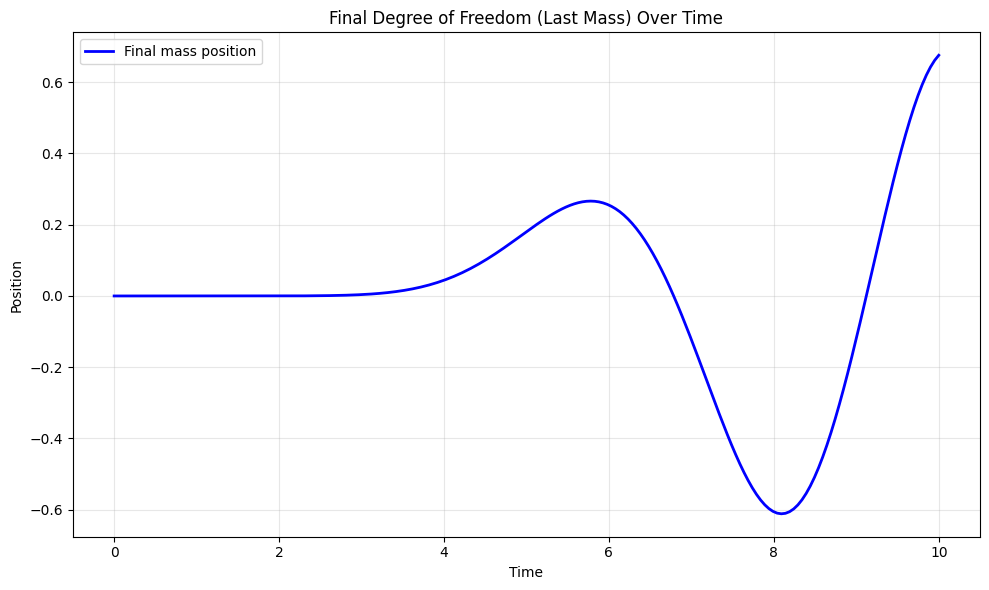

Final mass trajectory range: [-0.6116, 0.6758]


In [5]:
# Cell 5: Plot the final DOF over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Final mass position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Final Degree of Freedom (Last Mass) Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final mass trajectory range: [{target_traj.min():.4f}, {target_traj.max():.4f}]")


In [6]:
@jax.jit
def dynamics_clamped(state, t, p, x_clamped, v_clamped):
    """
    Clamped dynamics where the measurement DOF (final mass) position and velocity 
    exactly follow the target trajectory, while all accelerations are determined 
    by natural dynamics. This is a displacement and forcing control problem.
    
    The constraint forces emerge naturally from clamping displacement and velocity.
    """
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k_springs, beta = unpack_params(p)

    # Clamp the final mass position to exactly match the target trajectory
    x_clamped = x.at[N-1].set(jnp.interp(t, ts, target_traj))
    
    # Clamp the final mass velocity to match target trajectory derivative
    # Use JAX-compatible gradient computation to avoid boolean conversion errors
    target_vel = jnp.interp(t, ts, jnp.gradient(target_traj, ts))
    v_clamped = v.at[N-1].set(target_vel)

    # Compute accelerations for all masses using normal dynamics
    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x_clamped, jnp.array([0.0])])
    
    # linear spring forces with individual spring constants (vectorized)
    # For mass i: force = -k[i]*(x[i] - x[i-1]) - k[i+1]*(x[i] - x[i+1])
    left_neighbors = x_pad[0:N]      # [0, x[0], x[1], ..., x[N-2]]
    right_neighbors = x_pad[2:N+2]   # [x[1], x[2], ..., x[N-1], 0]
    left_springs = k_springs[0:N]    # spring constants for left connections
    right_springs = k_springs[1:N+1] # spring constants for right connections
    
    Kx = left_springs * (left_neighbors - x_clamped) + right_springs * (right_neighbors - x_clamped)
    
    # local Duffing nonlinearity
    duff = -beta * x_clamped**3
    # acceleration (forward time forcing)
    a = (Kx + duff + forcing(t)) / mass
    
    # Let natural dynamics determine all accelerations (including final mass)
    # The displacement and velocity clamping will create the constraint forces

    return jnp.concatenate([v_clamped, a])

=== Testing Clamped Dynamics Training Method ===
Clamped dynamics integration completed successfully!
Final mass clamping error: 1.06e-03


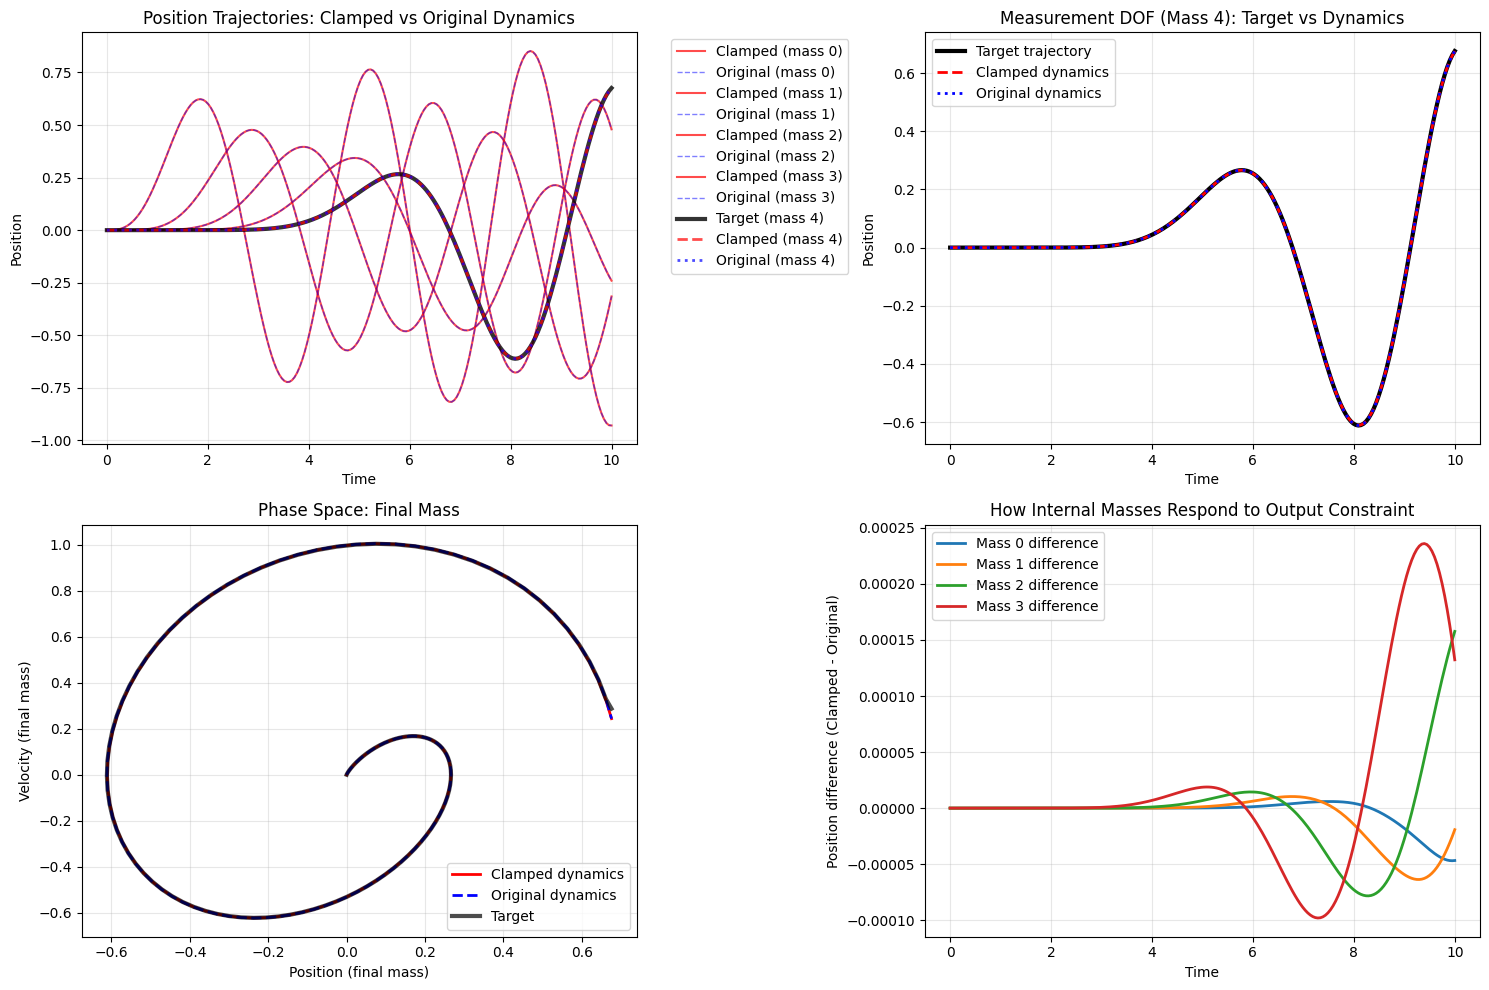


=== Analysis ===
Maximum clamping error: 1.06e-03
RMS difference in internal masses:
  Mass 0: 0.0000
  Mass 1: 0.0000
  Mass 2: 0.0000
  Mass 3: 0.0001

This demonstrates the new training method where:
1. The measurement DOF (mass 4) exactly follows the target
2. Internal masses adjust to satisfy this constraint
3. The system provides information about parameter sensitivity
4. Everything runs forward in time with applied forcing


In [7]:
# Cell 9: Test the new clamped dynamics method

print("=== Testing Clamped Dynamics Training Method ===")

# Test with different parameters to see how the system responds
p_test_clamped = p_true * 1.0  # Use different parameters than true ones

# Integrate the clamped dynamics
x_clamped = jnp.interp(ts, ts, target_traj)
v_clamped = jnp.gradient(x_clamped, ts)
states_clamped = odeint(dynamics_clamped, init_state, ts, p_test_clamped, x_clamped, v_clamped, rtol=1e-12, atol=1e-12)

# Extract trajectories
x_clamped = states_clamped[:, :N]  # positions of all masses
v_clamped = states_clamped[:, N:]  # velocities of all masses

# Compare with original dynamics and target
states_original = odeint(dynamics, init_state, ts, p_test_clamped, rtol=1e-12, atol=1e-12)
x_original = states_original[:, :N]

print("Clamped dynamics integration completed successfully!")
print(f"Final mass clamping error: {jnp.max(jnp.abs(x_clamped[:, N-1] - target_traj)):.2e}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Position trajectories comparison
ax = axes[0, 0]
for i in range(N):
    if i == N-1:  # final mass (measurement DOF)
        ax.plot(ts, target_traj, 'k-', linewidth=3, alpha=0.8, label=f'Target (mass {i})')
        ax.plot(ts, x_clamped[:, i], 'r--', linewidth=2, alpha=0.7, label=f'Clamped (mass {i})')
        ax.plot(ts, x_original[:, i], 'b:', linewidth=2, alpha=0.7, label=f'Original (mass {i})')
    else:
        ax.plot(ts, x_clamped[:, i], 'r-', linewidth=1.5, alpha=0.7, label=f'Clamped (mass {i})')
        ax.plot(ts, x_original[:, i], 'b--', linewidth=1, alpha=0.5, label=f'Original (mass {i})')

ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Position Trajectories: Clamped vs Original Dynamics')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Focus on measurement DOF
ax = axes[0, 1]
ax.plot(ts, target_traj, 'k-', linewidth=3, label='Target trajectory')
ax.plot(ts, x_clamped[:, N-1], 'r--', linewidth=2, label='Clamped dynamics')
ax.plot(ts, x_original[:, N-1], 'b:', linewidth=2, label='Original dynamics')
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title(f'Measurement DOF (Mass {N-1}): Target vs Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space of final mass
ax = axes[1, 0]
ax.plot(x_clamped[:, N-1], v_clamped[:, N-1], 'r-', linewidth=2, label='Clamped dynamics')
ax.plot(x_original[:, N-1], states_original[:, N+N-1], 'b--', linewidth=2, label='Original dynamics')
ax.plot(target_traj, jnp.gradient(target_traj, ts), 'k-', linewidth=3, alpha=0.7, label='Target')
ax.set_xlabel('Position (final mass)')
ax.set_ylabel('Velocity (final mass)')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Internal mass responses
ax = axes[1, 1]
for i in range(N-1):  # all masses except the final one
    ax.plot(ts, x_clamped[:, i] - x_original[:, i], 
            linewidth=2, label=f'Mass {i} difference')
ax.set_xlabel('Time')
ax.set_ylabel('Position difference (Clamped - Original)')
ax.set_title('How Internal Masses Respond to Output Constraint')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Analysis ===")
print(f"Maximum clamping error: {jnp.max(jnp.abs(x_clamped[:, N-1] - target_traj)):.2e}")
print(f"RMS difference in internal masses:")
for i in range(N-1):
    rms_diff = jnp.sqrt(jnp.mean((x_clamped[:, i] - x_original[:, i])**2))
    print(f"  Mass {i}: {rms_diff:.4f}")
    
print(f"\nThis demonstrates the new training method where:")
print(f"1. The measurement DOF (mass {N-1}) exactly follows the target")
print(f"2. Internal masses adjust to satisfy this constraint")
print(f"3. The system provides information about parameter sensitivity")
print(f"4. Everything runs forward in time with applied forcing")


In [8]:
@jax.jit
def _clamped_loss_fn(p, states_clamped):
    """
    Force matching loss function for clamped dynamics training.
    
    Strategy:
    1. Run free dynamics to get [v_free; a_free] for ALL DOFs  
    2. Loss = ||[v_clamped; a_clamped] - [v_free; a_free]||^2
    
    If parameters are correct, free dynamics should naturally match clamped behavior.
    """
    # Get clamped trajectory (measurement DOF follows target exactly)
    
    
    # Get free trajectory (all DOFs evolve naturally)  
    states_free = odeint(dynamics, init_state, ts, p, rtol=1e-12, atol=1e-12)
    
    # Extract velocities for all DOFs
    v_clamped = states_clamped[:, N:]  # velocities from clamped dynamics
    v_free = states_free[:, N:]        # velocities from free dynamics
    x_last_clamped = states_clamped[:, N-1]
    v_last_clamped = states_clamped[:, N+N-1]
    
    # Compute accelerations for all DOFs by evaluating dynamics functions
    def get_accelerations(states, dynamics_clamped_fn):
        """Extract accelerations by evaluating dynamics function at each time point"""
        # Use vmap to vectorize over states and time arrays
        vectorized_dynamics = jax.vmap(lambda state, t: dynamics_clamped_fn(state, t, p, x_last_clamped, v_last_clamped))
        dstates_dt = vectorized_dynamics(states, ts)
        accelerations = dstates_dt[:, N:]  # accelerations are second half
        return accelerations
    
    a_clamped = get_accelerations(states_clamped, dynamics_clamped)
    a_free = get_accelerations(states_free, dynamics)
    
    # Force matching loss: compare velocities and accelerations
    v_diff = v_clamped - v_free
    a_diff = a_clamped - a_free
    
    # Combined velocity and acceleration matching
    velocity_loss = 0.5 * jnp.trapezoid(jnp.sum(v_diff**2, axis=1), ts)
    acceleration_loss = 0.5 * jnp.trapezoid(jnp.sum(a_diff**2, axis=1), ts)
    
    return velocity_loss + acceleration_loss


In [9]:
def run_optimization(p_initial, n_steps, lr,loss_fn,states_clamped):
    clamped_loss_fn = lambda p: loss_fn(p, states_clamped)
    clamped_loss_grad = jax.jit(jax.grad(clamped_loss_fn))
    gd_step = lambda p, grad, lr: p - lr * grad

    p_current = p_initial
    losses = []

    print("Performing optimization steps...")
    for step in range(n_steps):
        grad = clamped_loss_grad(p_current)  # Use JIT-compiled gradient
        print(f"grad: {grad}")
        p_current = gd_step(p_current, grad, lr=lr)
        print(f"p_current: {p_current}")
        loss = clamped_loss_fn(p_current)
        losses.append(loss)
        if step % 1 == 0:
            print(f"  Step {step}: loss = {loss:.6f}")

    print(f"Final step: loss = {losses[-1]:.6f}")
    return p_current, losses

    
    

In [10]:

print("=== Free Dynamics vs Target Trajectory Comparison ===")

p_initial = p_true * 1.2  # 30% off from true values

states_clamped = odeint(dynamics_clamped, init_state, ts, p_initial,x_clamped,v_clamped, rtol=1e-12, atol=1e-12)

states_initial = odeint(dynamics, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)

p_current, losses = run_optimization(p_initial, 1000, 0.0008,_clamped_loss_fn,states_clamped)

# Run final free dynamics after optimization
states_final = odeint(dynamics, init_state, ts, p_current, rtol=1e-12, atol=1e-12)

# Get target trajectory and its velocity
target_x = target_traj  # position of final mass
target_v = jnp.gradient(target_traj, ts)  # velocity of final mass

# Extract final mass trajectories
x_initial_last = states_initial[:, N-1]   # initial free dynamics, last mass position
v_initial_last = states_initial[:, 2*N-1] # initial free dynamics, last mass velocity

x_final_last = states_final[:, N-1]       # final free dynamics, last mass position  
v_final_last = states_final[:, 2*N-1]     # final free dynamics, last mass velocity

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Position comparison
ax = axes[0, 0]
ax.plot(ts, target_x, 'k-', linewidth=3, label='Target trajectory', alpha=0.8)
ax.plot(ts, x_initial_last, 'r--', linewidth=2, label='Initial free dynamics', alpha=0.7)
ax.plot(ts, x_final_last, 'b-', linewidth=2, label='Optimized free dynamics', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Position')
ax.set_title('Final Mass Position: Target vs Free Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Velocity comparison
ax = axes[0, 1]
ax.plot(ts, target_v, 'k-', linewidth=3, label='Target velocity', alpha=0.8)
ax.plot(ts, v_initial_last, 'r--', linewidth=2, label='Initial free dynamics', alpha=0.7)
ax.plot(ts, v_final_last, 'b-', linewidth=2, label='Optimized free dynamics', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Velocity')
ax.set_title('Final Mass Velocity: Target vs Free Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Phase space comparison
ax = axes[1, 0]
ax.plot(target_x, target_v, 'k-', linewidth=3, label='Target', alpha=0.8)
ax.plot(x_initial_last, v_initial_last, 'r--', linewidth=2, label='Initial free', alpha=0.7)
ax.plot(x_final_last, v_final_last, 'b-', linewidth=2, label='Optimized free', alpha=0.7)

# Mark initial and final points
ax.scatter(target_x[0], target_v[0], color='black', s=100, marker='o', label='Start', zorder=5)
ax.scatter(target_x[-1], target_v[-1], color='black', s=100, marker='s', label='End', zorder=5)

ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title('Phase Space: Final Mass')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Optimization convergence
ax = axes[1, 1]
ax.semilogy(range(len(losses)), losses, 'bo-', linewidth=2, markersize=4)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Force Matching Loss (log scale)')
ax.set_title('Training Convergence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
print(f"\\n=== Quantitative Analysis ===")

# Position errors
pos_error_initial = jnp.sqrt(jnp.mean((x_initial_last - target_x)**2))
pos_error_final = jnp.sqrt(jnp.mean((x_final_last - target_x)**2))

print(f"Position RMS Error:")
print(f"  Initial: {pos_error_initial:.6f}")
print(f"  Final:   {pos_error_final:.6f}")
print(f"  Improvement: {pos_error_initial/pos_error_final:.2f}x")

# Velocity errors
vel_error_initial = jnp.sqrt(jnp.mean((v_initial_last - target_v)**2))
vel_error_final = jnp.sqrt(jnp.mean((v_final_last - target_v)**2))

print(f"\\nVelocity RMS Error:")
print(f"  Initial: {vel_error_initial:.6f}")
print(f"  Final:   {vel_error_final:.6f}")
print(f"  Improvement: {vel_error_initial/vel_error_final:.2f}x")

# Parameter recovery
param_error_initial = jnp.linalg.norm(p_initial - p_true)
param_error_final = jnp.linalg.norm(p_current - p_true)

print(f"\\nParameter Recovery:")
print(f"  Initial ||p - p_true||: {param_error_initial:.6f}")
print(f"  Final ||p - p_true||:   {param_error_final:.6f}")
print(f"  Improvement: {param_error_initial/param_error_final:.2f}x")

print(f"\\nLoss Reduction:")
print(f"  Initial loss: {losses[0]:.8f}")
print(f"  Final loss:   {losses[-1]:.8f}")
print(f"  Reduction: {losses[0]/losses[-1]:.2f}x")

print(f"\\n=== Demonstration Complete ===")
print("This shows how force matching training drives the free dynamics")
print("to naturally match the target trajectory without explicit constraints!")


=== Free Dynamics vs Target Trajectory Comparison ===
Performing optimization steps...


TypeError: dynamics() takes 3 positional arguments but 5 were given

In [ ]:
states_free = odeint(dynamics, init_state, ts, p_initial, rtol=1e-12, atol=1e-12)
x_last_interpolated = lambda alpha: (1 - alpha) * states_free[:,N-1] + alpha * states_clamped[:,N-1]

p_alpha = p_initial 

alphas = jnp.linspace(0, 1, 100)
for alpha in alphas:
    x_last_interpolated = x_last_interpolated(alpha)
    v_last_interpolated = jnp.gradient(x_last_interpolated, ts)
    states_clamped = odeint(dynamics_clamped, init_state, ts, p_alpha, x_last_interpolated, v_last_interpolated, rtol=1e-12, atol=1e-12)
    
    p_alpha, losses = run_optimization(p_alpha, 1000, 0.0008,_clamped_loss_fn,states_clamped)
    











In [ ]:
alphas = jnp.linspace(0, 1, 100)

for alpha in alphas:
    x_interpolated = (1 - alpha) * x_free_last + alpha * target_traj
    v_interpolated = jnp.gradient(x_interpolated, ts)
    a_interpolated = jnp.gradient(v_interpolated, ts)
    F_needed = a_interpolated
    F_network = jnp.zeros_like(ts)
    for i, t in enumerate(ts):
        x_t = x_states[i]
        v_t = v_states[i]